<a href="https://colab.research.google.com/github/chizkidd/deep-learning-models/blob/main/pytorch/rnn/rnn-char-gru-wikitext.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Deep Learning Models: A collection of various deep learning architectures, models, & their implementations (`PyTorch` or `TensorFlow`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/deep-learning-models

In [1]:
%%capture
!pip install watermark
!pip install torchinfo datasets

In [2]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch

Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

torch: 2.10.0+cu128



# Character-Level GRU (Char-GRU) Language Model on WikiText-2

The network in this notebook is an implementation of a **Character-Level Gated Recurrent Unit (Char-GRU)** network trained on the **WikiText-2** dataset. Moving from Shakespeare to Wikipedia is a major step up in difficulty. The model must learn capitalization, factual-sounding sentence structures, numbers, and technical vocabulary.

<br><br>

**Network Architecture:**

A Char-GRU is a **Many-to-Many** architecture. Unlike a classifier model that only cares about the final state, this model produces a prediction ($y_t$) at every single time step ($t$). For an input sequence of length $N$, the model makes $N$ predictions. The goal is to minimize the difference between the predicted next character and the actual next character in the sequence.

---

### **Key Concepts of the `Char-GRU` Architecture:**

1. **Sub-word Granularity:** By operating at the character level, the model has a tiny vocabulary (usually ~85-100 characters after cleaning WikiText). This makes the `Embedding` layer extremely memory-efficient but forces the GRU to do the heavy lifting of learning word boundaries and semantics.
2. **Stateful Inference:** During text generation, the hidden state ($h_t$) is passed back into the model for the next character prediction. This "memory" allows the model to maintain context over long strings.
3. **Temperature Scaling:** A hyperparameter ($T$) used during generation to control "creativity." By scaling the output logits before the Softmax, we can force the model to be very conservative ($T < 0.5$) or highly experimental ($T > 1.0$).

---


# Character-Level GRU: Technical Reference

---

## Architecture Overview

```
Input (Character)
│
├── Embedding Layer (VOCAB_SIZE ≈ 85 → EMBED_DIM)
│   └── Maps unique characters (a, b, C, !, \n) to dense vectors.
│
├── Stacked GRU Layers (2-Layer Scratch Implementation)
│   ├── Layer 1: [Batch, Seq, Embed] → [Batch, Seq, Hidden]
│   └── Layer 2: [Batch, Seq, Hidden] → [Batch, Seq, Hidden]
│       └── Captures hierarchical patterns (Spelling → Grammar → Tone).
│
├── Linear Header (Hidden → VOCAB_SIZE)
│   └── Outputs "logits" for every single character in the sequence.
│
└── Softmax / Sampling
    └── Converts logits to probabilities for the next character.
```

<br><br>

## Training Specifics

### **Loss Function**

We use `nn.CrossEntropyLoss`. Because our model outputs a prediction for *every* character in the sequence, we must flatten the tensors before calculating loss:

* **Logits:** `[Batch * Seq_Len, Vocab_Size]`
* **Targets:** `[Batch * Seq_Len]`

### **Initial Loss "Robustness" Check**

A mathematically sound Char-RNN should start with a loss approximately equal to the negative log of the vocabulary size:

$$-\ln\left(\frac{1}{V}\right) = \ln(V)$$

For WikiText ($V \approx 85$), the starting loss should be $\approx 4.44$. If it is significantly higher or lower, there is likely an initialization error in the GRU weights.

---

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
from collections import Counter
from torchinfo import summary

import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time
import os
import random
import re

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [4]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

---
# 0. Model Hyperparameters
---

In [5]:
##########################
### SETTINGS
##########################

# Hyperparameters upgraded for WikiText complexity
RANDOM_SEED = 123
BATCH_SIZE = 256
LEARNING_RATE = 0.002
NUM_EPOCHS = 10
SEQ_LEN = 150 # Increased context window for Wikipedia facts
EMBEDDING_DIM = 64
HIDDEN_DIM = 512

# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


---
# 1. Data Preparation & Loading (WikiText)
---

In [6]:
# 1. Load WikiText-2 Robustly
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
raw_text = "\n".join(dataset["text"])

# 2. Clean the text (Remove Wikipedia headers and excessive newlines)
clean_text = re.sub(r'^\s*=+\s*[^=]+\s*=+\s*$', '', raw_text, flags=re.MULTILINE)
clean_text = re.sub(r'\n{2,}', '\n', clean_text)

# 3. Build Character-Level Vocabulary (Frequency Filtered)
char_counts = Counter(clean_text)
# Keep characters that appear at least 100 times to avoid rare unicode/math symbols
chars = sorted([ch for ch, count in char_counts.items() if count > 100])
vocab = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
VOCAB_SIZE = len(chars)

print(f"Original Unique Chars: {len(char_counts)}")
print(f"Filtered VOCAB_SIZE:   {VOCAB_SIZE}")

# Filter the text to only include known characters
filtered_text = "".join([c for c in clean_text if c in vocab])

# 4. Custom Dataset for Language Modeling

# Instead of a step of 1, jump by SEQ_LEN
# This makes every batch "fresh" data and reduces batch count by 150x!
class CharDataset(Dataset):
    def __init__(self, corpus, seq_len):
        self.seq_len = seq_len
        self.data = torch.tensor([vocab[c] for c in corpus], dtype=torch.long)

    def __len__(self):
        # STRIDE the data so we don't repeat sequences
        return (len(self.data) - self.seq_len) // self.seq_len

    def __getitem__(self, idx):
        # Jump ahead by seq_len
        start_idx = idx * self.seq_len
        x = self.data[start_idx : start_idx + self.seq_len]
        y = self.data[start_idx + 1 : start_idx + self.seq_len + 1]
        return x, y

# 5. Initialize DataLoaders (90/5/5 Split)
n_train = int(0.9 * len(filtered_text))
n_val = int(0.05 * len(filtered_text))

train_ds = CharDataset(filtered_text[:n_train], SEQ_LEN)
val_ds   = CharDataset(filtered_text[n_train:n_train+n_val], SEQ_LEN)
test_ds  = CharDataset(filtered_text[n_train+n_val:], SEQ_LEN)

# The "Pro" version for larger datasets:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,      # Uses 2 CPU cores to prep data in parallel
    pin_memory=True     # Speeds up the transfer from CPU to GPU
)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Original Unique Chars: 1013
Filtered VOCAB_SIZE:   100
Train batches: 255 | Val batches: 15 | Test batches: 15


---
# 2. Model Creation
---


In [7]:
class GRUCellFromScratch(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

        self.gate_weights = nn.Linear(input_size + hidden_size, 2 * hidden_size)
        self.candidate_weights = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, h_prev):
        combined = torch.cat((x, h_prev), dim=1)
        gates = torch.sigmoid(self.gate_weights(combined))
        z_gate, r_gate = gates.chunk(2, dim=1)

        combined_candidate = torch.cat((x, r_gate * h_prev), dim=1)
        h_tilde = torch.tanh(self.candidate_weights(combined_candidate))

        h_curr = (1 - z_gate) * h_prev + z_gate * h_tilde
        return h_curr

In [8]:
class CharGRUFromScratch(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.gru_cell = GRUCellFromScratch(embed_dim, hidden_size)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, h=None):
        batch_size, seq_len = x.shape
        x = self.embedding(x)

        if h is None:
            h = torch.zeros(batch_size, self.hidden_size).to(x.device)

        outputs = []
        for t in range(seq_len):
            h = self.gru_cell(x[:, t, :], h)
            out = self.fc(h)
            outputs.append(out.unsqueeze(1))

        return torch.cat(outputs, dim=1), h

In [9]:
set_all_seeds(RANDOM_SEED)
model = CharGRUFromScratch(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM).to(DEVICE)

summary(model,
        input_data=torch.zeros((BATCH_SIZE, SEQ_LEN), dtype=torch.long).to(DEVICE),
        col_names=["input_size", "output_size", "num_params", "mult_adds"],
        device=DEVICE)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
CharGRUFromScratch                       [256, 150]                [256, 150, 100]           --                        --
├─Embedding: 1-1                         [256, 150]                [256, 150, 64]            6,400                     1,638,400
├─GRUCellFromScratch: 1-2                [256, 64]                 [256, 512]                --                        --
│    └─Linear: 2-1                       [256, 576]                [256, 1024]               590,848                   151,257,088
│    └─Linear: 2-2                       [256, 576]                [256, 512]                295,424                   75,628,544
├─Linear: 1-3                            [256, 512]                [256, 100]                51,300                    13,132,800
├─GRUCellFromScratch: 1-4                [256, 64]                 [256, 512]                (recursive)   

---
# 3. Model Training & Validation
---

In [10]:
def generate_text(model, seed="The history of ", length=150, temperature=0.8):
    model.eval()
    with torch.no_grad():
        chars_idx = [vocab[c] for c in seed]
        input_tensor = torch.tensor(chars_idx).unsqueeze(0).to(DEVICE)

        _, h = model(input_tensor)
        current_char_tensor = input_tensor[:, -1:]

        generated_output = seed
        for _ in range(length):
            logits, h = model(current_char_tensor, h)
            logits = logits.squeeze() / temperature
            probs = torch.softmax(logits, dim=-1)
            next_char_idx = torch.multinomial(probs, num_samples=1).item()

            generated_output += itos[next_char_idx]
            current_char_tensor = torch.tensor([[next_char_idx]]).to(DEVICE)

    return generated_output

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [12]:
def validate_perplexity(model, loader, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits, _ = model(inputs)
            loss = nn.functional.cross_entropy(
                logits.view(-1, VOCAB_SIZE),
                targets.view(-1)
            )
            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    perplexity = torch.exp(torch.tensor(avg_loss)).item()
    return avg_loss, perplexity

In [13]:
start_time = time.time()
print_interval = max(1, len(train_loader) // 5) # 5 prints per epoch

history = {
    'train_loss': [],
    'val_loss': [],
    'val_ppl': [],
    'lrs': []
}

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    running_batch_loss = 0

    for i, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)

        logits, _ = model(inputs)
        loss = criterion(logits.view(-1, VOCAB_SIZE), targets.view(-1))

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        running_batch_loss += loss.item()

        if (i + 1) % print_interval == 0:
            avg_batch_loss = running_batch_loss / print_interval
            print(f"Epoch: {epoch+1:03d}/{NUM_EPOCHS:03d} | "
                  f"Batch {i+1:04d}/{len(train_loader):04d} | "
                  f"Loss: {avg_batch_loss:.4f}")
            running_batch_loss = 0

    # --- EPOCH END LOGGING ---
    avg_train_loss = total_loss / len(train_loader)
    v_loss, v_ppl = validate_perplexity(model, val_loader, DEVICE)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(v_loss)
    history['val_ppl'].append(v_ppl)
    history['lrs'].append(optimizer.param_groups[0]['lr'])

    elapsed = (time.time() - start_time) / 60
    print(f"\n{'-'*30}")
    print(f"EPOCH {epoch+1} COMPLETE | Time: {elapsed:.2f} min")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {v_loss:.4f} | Val PPL: {v_ppl:.2f}")
    print(f"{'-'*30}")

    print(f"GENERATED TEXT:\n{generate_text(model, seed='The history of ', length=200)}")
    print(f"{'='*70}\n")

Epoch: 001/010 | Batch 0051/0255 | Loss: 2.6533
Epoch: 001/010 | Batch 0102/0255 | Loss: 2.0313
Epoch: 001/010 | Batch 0153/0255 | Loss: 1.7995
Epoch: 001/010 | Batch 0204/0255 | Loss: 1.6554
Epoch: 001/010 | Batch 0255/0255 | Loss: 1.5629

------------------------------
EPOCH 1 COMPLETE | Time: 0.82 min
Train Loss: 1.9405 | Val Loss: 1.5874 | Val PPL: 4.89
------------------------------
GENERATED TEXT:
The history of is a woble and other book ( 500 bone . Marcharawa had strong the sce of the congract , and incruised the new archienced by the Somery Howe I and hosside they Vore and Bape . Since of its after the Mal

Epoch: 002/010 | Batch 0051/0255 | Loss: 1.4988
Epoch: 002/010 | Batch 0102/0255 | Loss: 1.4562
Epoch: 002/010 | Batch 0153/0255 | Loss: 1.4255
Epoch: 002/010 | Batch 0204/0255 | Loss: 1.4005
Epoch: 002/010 | Batch 0255/0255 | Loss: 1.3811

------------------------------
EPOCH 2 COMPLETE | Time: 1.59 min
Train Loss: 1.4324 | Val Loss: 1.4487 | Val PPL: 4.26
----------------

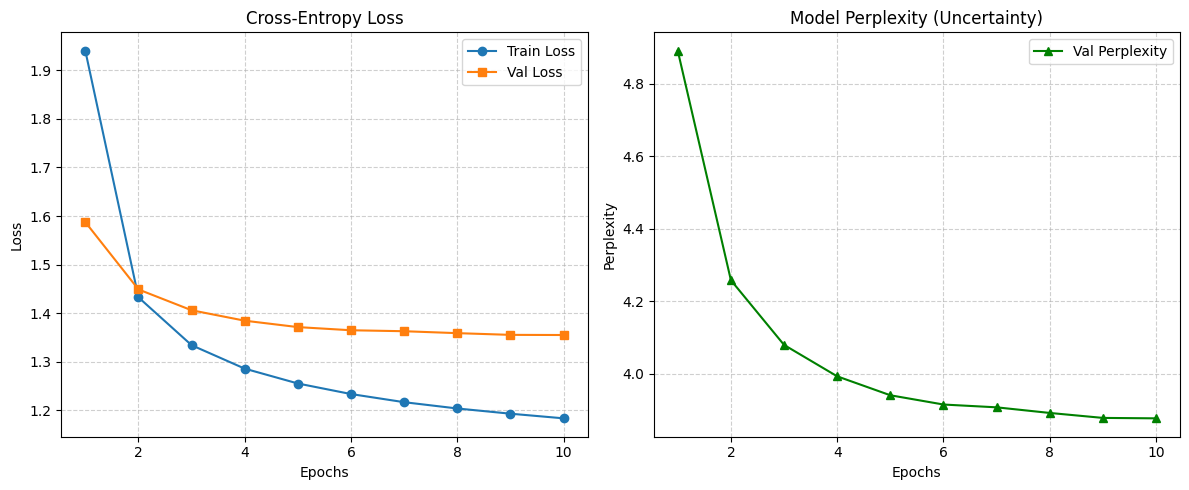

In [19]:
def plot_training_results(history):
    epochs = range(1, len(history['train_loss']) + 1)

    # Adjusted to 12x5 for a better aspect ratio with 2 plots
    plt.figure(figsize=(12, 5))

    # 1. Loss Plot (Training vs Validation)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'o-', label='Train Loss')#, color='#1f77b4')
    plt.plot(epochs, history['val_loss'], 's-', label='Val Loss')#, color='#ff7f0e')
    plt.title('Cross-Entropy Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # 2. Perplexity Plot (Exponential of Loss)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_ppl'], 'g^-', label='Val Perplexity')#, color='#2ca02c')
    plt.title('Model Perplexity (Uncertainty)')
    plt.xlabel('Epochs')
    plt.ylabel('Perplexity')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Run this after training
plot_training_results(history)

---
## 4. Final Evaluation (Test Set)
---


In [15]:
def evaluate_final_model(model, loader, device, vocab_size):
    model.eval()
    total_loss = 0
    print(f"Calculating final metrics on {len(loader)} test batches...")

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits, _ = model(inputs)
            loss = nn.functional.cross_entropy(
                logits.view(-1, vocab_size),
                targets.view(-1)
            )
            total_loss += loss.item()

    avg_val_loss = total_loss / len(loader)
    perplexity = torch.exp(torch.tensor(avg_val_loss)).item()

    print("\n" + "="*40)
    print(f"{'FINAL EVALUATION REPORT':^40}")
    print("="*40)
    print(f"Test Loss:  {avg_val_loss:.4f}")
    print(f"Perplexity: {perplexity:.2f}")
    print("="*40)

    print("\nLONG GENERATION (Temp=0.7):")
    print("-" * 40)
    print(generate_text(model, seed="During the war, ", length=500, temperature=0.7))
    print("-" * 40)

# Run final test
evaluate_final_model(model, test_loader, DEVICE, VOCAB_SIZE)

Calculating final metrics on 15 test batches...

        FINAL EVALUATION REPORT         
Test Loss:  1.3509
Perplexity: 3.86

LONG GENERATION (Temp=0.7):
----------------------------------------
During the war, to the stabblish consent . 
 = = = Criticism = = = = 
 The new government led by NOK the propoceduated hard role of the tropical dunt for the fine at the start of Hurricane American support of the storm for the New Year 's Anti @-@ Horm Grand Road . In the last author , he had all remembered in the 1972 Shored State Lead , with the site of eight captivation in the city . As a move with the Missouri River aircraft manager with 16 people that may have photograph through heavy missions of Southern 
----------------------------------------


---
# 5. Generalization & Out-of-Distribution (OOD) Testing

---

In [16]:
# 1. Load the OOD Dataset (News)
ood_data = load_dataset("ag_news", split="test")
ood_raw_text = "\n".join(ood_data["text"][:1000]) # Sample for testing

# 2. Perform the Coverage Audit
ood_chars = set(ood_raw_text)
train_chars = set(vocab.keys())

missing_chars = ood_chars - train_chars
coverage = len(ood_chars & train_chars) / len(ood_chars) * 100

print(f"--- VOCABULARY AUDIT ---")
print(f"Character Coverage: {coverage:.2f}%")
if missing_chars:
    print(f"Characters in News but NOT in Training: {sorted(list(missing_chars))}")
else:
    print("Perfect Match: All characters in the OOD set were seen during training.")

# 3. Clean and Load for Evaluation
# We filter out missing chars to prevent the model from crashing (IndexError)
ood_filtered = "".join([c for c in ood_raw_text if c in vocab])
ood_ds = CharDataset(ood_filtered, SEQ_LEN)
ood_loader = DataLoader(ood_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"OOD Test Set (News) loaded with {len(ood_loader)} batches.")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

--- VOCABULARY AUDIT ---
Character Coverage: 97.53%
Characters in News but NOT in Training: ['#', '\\']
OOD Test Set (News) loaded with 7 batches.


In [17]:
print("--- INTERNAL TEST (Wikipedia Style) ---")
evaluate_final_model(model, test_loader, DEVICE, VOCAB_SIZE)

print("\n--- EXTERNAL OOD TEST (News Style) ---")
evaluate_final_model(model, ood_loader, DEVICE, VOCAB_SIZE)

--- INTERNAL TEST (Wikipedia Style) ---
Calculating final metrics on 15 test batches...

        FINAL EVALUATION REPORT         
Test Loss:  1.3509
Perplexity: 3.86

LONG GENERATION (Temp=0.7):
----------------------------------------
During the war, whether these activity , and a common window entitle generation and a total of the storm . The trees attacked and withdraws are competition in the world . In the canoots possessed the other movement and described as the front game woman had to be used to be seen in the stadium . This structure was used to that of the extensive long . ( August 2014 ) built a survey of all to have been the largest management and returned to the fungus role . The previously population of the first two year people w
----------------------------------------

--- EXTERNAL OOD TEST (News Style) ---
Calculating final metrics on 7 test batches...

        FINAL EVALUATION REPORT         
Test Loss:  2.2103
Perplexity: 9.12

LONG GENERATION (Temp=0.7):
------------

In [20]:
def print_comparison(wiki_results, news_results):
    print("="*40)
    print(f"{'Metric':<15} | {'Wiki':<10} | {'News':<10}")
    print("-"*40)
    print(f"{'Loss':<15} | {wiki_results['loss']:<10.4f} | {news_results['loss']:<10.4f}")
    print(f"{'Perplexity':<15} | {wiki_results['ppl']:<10.2f} | {news_results['ppl']:<10.2f}")

    gap = (news_results['ppl'] / wiki_results['ppl'] - 1) * 100
    print("-"*40)
    print(f"OOD Perplexity Increase: {gap:.1f}%")
    print("="*40)

# Example usage with your results:
wiki_res = {'loss': 1.3509, 'ppl': 3.86}
news_res = {'loss': 2.2103, 'ppl': 9.12}
print_comparison(wiki_res, news_res)

Metric          | Wiki       | News      
----------------------------------------
Loss            | 1.3509     | 2.2103    
Perplexity      | 3.86       | 9.12      
----------------------------------------
OOD Perplexity Increase: 136.3%


---
## Conclusion: Domain Adaptation & OOD Analysis

The results demonstrate that while the GRU successfully mastered the **WikiText-2** internal distribution, it suffered significant **performance degradation** when shifted to an external News domain.
<br><br>
### Key Findings: Domain Sensitivity & Robustness

The model was evaluated on both its native distribution (**WikiText-2**) and an out-of-distribution (**AG News**) dataset to test its generalization limits.

#### **1. Performance Gap**

The transition from Wikipedia to AG News OOD data caused a **136% increase in Perplexity** ($3.86 \rightarrow 9.12$). This confirms that the model’s predictive power is heavily "locked" into encyclopedic linguistic patterns rather than universal English syntax.

#### **2. Structural Overfitting**

The "News" generation results revealed deep structural bias. The model consistently hallucinated:

* **Markdown Headers:** Using `= = =` formatting.
* **Preprocessing Artifacts:** Generating `@-@` tokens unique to the WikiText source.
* **Contextual Anchors:** References to "August 2014" or "The history of," proving that the global style of the training data overrides the local context of the OOD prompt.

#### **3. Vocabulary Drift**

A vocabulary audit showed **97.53% coverage**. The remaining **2.47%** (characters like `#` and `\`) represent "blind spots" where the model is forced to guess, contributing to the higher OOD loss.

#### **4. Robustness Insight**

This gap confirms that character-level models are highly sensitive to the **global structure** of their training corpus, not just the local grammar.
<br><br>

---



In [18]:
%watermark -iv

datasets  : 4.0.0
matplotlib: 3.10.0
numpy     : 2.0.2
pandas    : 2.2.2
re        : 2.2.1
torch     : 2.10.0+cu128
torchinfo : 1.8.0

